In [11]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import netket as nk
import netket.experimental as nkx
import sys
sys.path.append('..')
from NES_VMC import NESTotalAnsatz, create_machine,\
    SingleStateAnsatz,create_single_machine,\
    create_machine_matrix,Ham_psi,Ham_Psi,NES_loss_energy,nes_vmc_gradient,\
    NESFermionHopRule,compute_qgt,sampler_info,\
    create_machine_matrix_stable,create_single_machine_gauge_fixed,create_machine_max_stable,\
    NESTotalAnsatz_stable,create_machine_stable,NES_loss_energy_stable,nes_vmc_gradient_stable,\
    make_grad_fn,make_qgt_fn
import optax
from scipy.sparse.linalg import eigsh
from typing import Callable
from functools import partial
from jax.flatten_util import ravel_pytree
import time
import itertools
from pyscf import gto, scf, fci
import numpy as np


jnp.set_printoptions(
    linewidth=9999,
    threshold=jnp.inf,
    precision=8,
    suppress=False,
)


geometry = [
    ("H", (0.0, 0.0, 0.0)),
]

mol = gto.M(atom=geometry, basis="cc-pVDZ", verbose=0, spin=1)
mf = scf.RHF(mol).run(verbose=0)
hf_ground_energy = mf.e_tot


K = 4
cisolver = fci.FCI(mf)
cisolver.nroots = K
E_fcis, fcivec = cisolver.kernel()

print("=" * 60)
print("H原子 / cc-pVDZ 基准")
print("=" * 60)
print(f"HF energy = {hf_ground_energy:.8f} Ha")
for i, e in enumerate(E_fcis):
    exc = (e - E_fcis[0]) * 27.2114
    print(f"E{i} = {e:.8f} Ha | excitation = {exc:.4f} eV")

hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=5,
    s=1/2,
    n_fermions_per_spin=(1, 0),
)


hi_ext = hi ** K
ha = nkx.operator.from_pyscf_molecule(mol)

SINGLE_SIZE = hi.size

print("=" * 60)
print("Hilbert 信息")
print("=" * 60)
print(f"K = {K}")
print(f"hi.size = {hi.size}")
print(f"hi_ext.size = {hi_ext.size}")
print(f"SINGLE_SIZE = {SINGLE_SIZE}")

target_loss = float(np.sum(E_fcis[:K]))
print(f"target_loss = sum(E_fcis[:K]) = {target_loss:.8f}")


Hatree_Fock = hi.all_states()[0]
Hatree_Fock

H原子 / cc-pVDZ 基准
HF energy = -0.49927840 Ha
E0 = -0.49927840 Ha | excitation = 0.0000 eV
E1 = 0.18193257 Ha | excitation = 18.5367 eV
E2 = 0.91041914 Ha | excitation = 38.3598 eV
E3 = 0.91041914 Ha | excitation = 38.3598 eV
Hilbert 信息
K = 4
hi.size = 10
hi_ext.size = 40
SINGLE_SIZE = 10
target_loss = sum(E_fcis[:K]) = 1.50349245


Array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0], dtype=int8)

In [7]:
single_edges_full = [(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4), (4, 5),]   
ext_edges = []
for k in range(K):
    offset = k * SINGLE_SIZE
    for i, j in single_edges_full:
        ext_edges.append((i + offset, j + offset))

ext_edges = jnp.asarray(ext_edges)

nes_rule = NESFermionHopRule(
    edges=ext_edges,
    K=K,
    single_size=SINGLE_SIZE,
)
print(single_edges_full)

[(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4), (4, 5)]


In [9]:
import logging
# 日志配置
logger = logging.getLogger('NES_VMC_K4')
logger.setLevel(logging.INFO)
# 阻止日志向上传播
logger.propagate = False
# 清除所有旧handler，防止重复打印
logger.handlers.clear()

# 自定义日志格式：只打印内容，不带等级、logger名
simple_formatter = logging.Formatter("%(message)s", datefmt="%H:%M:%S")

# 1. 文件输出处理器
file_handler = logging.FileHandler("nes_vmc_0709_K3_H2_ccpVDZ.log", mode="w", encoding="utf-8")
file_handler.setFormatter(simple_formatter)
file_handler.setLevel(logging.INFO)
logger.addHandler(file_handler)

console_handler = logging.StreamHandler()
console_handler.setFormatter(simple_formatter)
console_handler.setLevel(logging.INFO)
logger.addHandler(console_handler)

print('库导入完成')

库导入完成


In [ ]:
# ============================================================
# 诊断函数 - 从 Stable 版本移植
# ============================================================

def tree_l2_norm(tree):
    leaves = jax.tree_util.tree_leaves(tree)
    if len(leaves) == 0:
        return jnp.array(0.0)
    return jnp.sqrt(
        sum([jnp.sum(jnp.abs(x) ** 2) for x in leaves])
    )


def tree_all_finite(tree):
    leaves = jax.tree_util.tree_leaves(tree)
    if len(leaves) == 0:
        return True
    flags = [jnp.all(jnp.isfinite(x)) for x in leaves]
    return bool(jnp.all(jnp.asarray(flags)))


def unique_ratio_from_samples(samples):
    """
    samples: shape (n_samples, hi_ext.size)
    """
    arr = np.asarray(samples)
    arr = arr.reshape(arr.shape[0], -1)
    unique = len({tuple(row.tolist()) for row in arr})
    return unique / max(arr.shape[0], 1)


def tree_batch_std_norm(tree, batch_size):
    leaves = jax.tree_util.tree_leaves(tree)
    total = 0.0
    for leaf in leaves:
        if leaf.ndim >= 1 and leaf.shape[0] == batch_size:
            centered = leaf - jnp.mean(leaf, axis=0, keepdims=True)
            total = total + jnp.sum(jnp.abs(centered) ** 2)
    return jnp.sqrt(total)


def tree_batch_mean_norm(tree, batch_size):
    leaves = jax.tree_util.tree_leaves(tree)
    total = 0.0
    for leaf in leaves:
        if leaf.ndim >= 1 and leaf.shape[0] == batch_size:
            mean_leaf = jnp.mean(leaf, axis=0)
            total = total + jnp.sum(jnp.abs(mean_leaf) ** 2)
    return jnp.sqrt(total)


def compute_diagnostics_original(
    total_params,
    x_batch,
    samples,
    E_L_mean,
    total_machine,
    total_matrix_machine,
    single_machine_list,
    ha,
    K,
):
    """
    返回当前参数下的完整诊断量 (适配原版非稳定函数)
    """
    n_total = x_batch.shape[0]
    n_diag = min(128, n_total)  # 诊断用的batch大小

    x_diag = x_batch[:n_diag]
    samples_diag = samples[:n_diag]

    # ---------- logΨ 统计 ----------
    log_Psi_batch = jax.vmap(
        lambda xx: total_machine(total_params, xx)
    )(x_batch)

    log_real = jnp.real(log_Psi_batch)
    log_imag = jnp.imag(log_Psi_batch)

    log_real_mean = jnp.mean(log_real)
    log_real_std = jnp.std(log_real)
    log_real_span = jnp.max(log_real) - jnp.min(log_real)

    log_imag_mean = jnp.mean(log_imag)
    log_imag_std = jnp.std(log_imag)
    log_imag_span = jnp.max(log_imag) - jnp.min(log_imag)

    # ---------- Ψ矩阵条件数 ----------
    L_diag = total_matrix_machine(total_params, x_diag)
    Psi_diag = jnp.exp(L_diag)

    try:
        conds = jax.vmap(jnp.linalg.cond)(Psi_diag)
        psi_cond_first = conds[0]
        psi_cond_mean = jnp.mean(conds)
        psi_cond_max = jnp.max(conds)
    except:
        psi_cond_first = jnp.array(0.0)
        psi_cond_mean = jnp.array(0.0)
        psi_cond_max = jnp.array(0.0)

    # ---------- E_L_batch / trace 统计 ----------
    try:
        trace_batch, E_L_batch = NES_loss_energy(
            ha=ha,
            total_matrix_machine=total_matrix_machine,
            single_machine_list=single_machine_list,
            total_params=total_params,
            x=x_diag,
        )
        trace_real = jnp.real(trace_batch)
        trace_imag = jnp.imag(trace_batch)

        trace_real_mean = jnp.mean(trace_real)
        trace_real_std = jnp.std(trace_real)
        trace_real_span = jnp.max(trace_real) - jnp.min(trace_real)

        trace_imag_mean = jnp.mean(trace_imag)
        trace_imag_std = jnp.std(trace_imag)
        trace_imag_span = jnp.max(trace_imag) - jnp.min(trace_imag)
    except:
        trace_real_mean = jnp.array(0.0)
        trace_real_std = jnp.array(0.0)
        trace_real_span = jnp.array(0.0)
        trace_imag_mean = jnp.array(0.0)
        trace_imag_std = jnp.array(0.0)
        trace_imag_span = jnp.array(0.0)
        E_L_batch = None

    # ---------- E_L_mean Hermiticity ----------
    if E_L_mean is not None:
        herm_error = (
            jnp.linalg.norm(E_L_mean - E_L_mean.conj().T)
            / (jnp.linalg.norm(E_L_mean) + 1e-12)
        )
        imag_norm = jnp.linalg.norm(jnp.imag(E_L_mean))
        E_L_herm = 0.5 * (E_L_mean + E_L_mean.conj().T)
        try:
            eig_vals_herm = jnp.linalg.eigvalsh(E_L_herm)
        except:
            eig_vals_herm = jnp.array([0.0, 0.0])
        try:
            eig_vals_raw = jnp.linalg.eigvals(E_L_mean)
            eig_vals_raw = eig_vals_raw[jnp.argsort(jnp.real(eig_vals_raw))]
        except:
            eig_vals_raw = jnp.array([0.0, 0.0])
    else:
        herm_error = jnp.array(0.0)
        imag_norm = jnp.array(0.0)
        eig_vals_herm = jnp.array([0.0, 0.0])
        eig_vals_raw = jnp.array([0.0, 0.0])

    # ---------- sampler unique ratio ----------
    unique_ratio = unique_ratio_from_samples(samples_diag)

    # ---------- dlogΨ batch 方差 ----------
    try:
        grad_logPsi = jax.grad(total_machine, argnums=0, holomorphic=True)
        dlogPsi_batch = jax.vmap(
            grad_logPsi,
            in_axes=(None, 0),
        )(total_params, x_diag)

        dlog_std_norm = tree_batch_std_norm(dlogPsi_batch, n_diag)
        dlog_mean_norm = tree_batch_mean_norm(dlogPsi_batch, n_diag)
        dlog_std_ratio = dlog_std_norm / (dlog_mean_norm + 1e-12)
    except:
        dlog_std_norm = jnp.array(0.0)
        dlog_mean_norm = jnp.array(0.0)
        dlog_std_ratio = jnp.array(0.0)

    return {
        "log_Psi_batch": log_Psi_batch,
        "log_real_mean": log_real_mean,
        "log_real_std": log_real_std,
        "log_real_span": log_real_span,
        "log_imag_mean": log_imag_mean,
        "log_imag_std": log_imag_std,
        "log_imag_span": log_imag_span,
        "psi_cond_first": psi_cond_first,
        "psi_cond_mean": psi_cond_mean,
        "psi_cond_max": psi_cond_max,
        "trace_real_mean": trace_real_mean,
        "trace_real_std": trace_real_std,
        "trace_real_span": trace_real_span,
        "trace_imag_mean": trace_imag_mean,
        "trace_imag_std": trace_imag_std,
        "trace_imag_span": trace_imag_span,
        "herm_error": herm_error,
        "imag_norm": imag_norm,
        "eig_vals_herm": eig_vals_herm,
        "eig_vals_raw": eig_vals_raw,
        "unique_ratio": unique_ratio,
        "dlog_std_norm": dlog_std_norm,
        "dlog_mean_norm": dlog_mean_norm,
        "dlog_std_ratio": dlog_std_ratio,
    }


def log_diagnostics_original(step, loss_mean, grad_norm_raw, grad_norm_update, grad_norm_clipped, diag, target_loss, K, clip_norm=1.0):
    eig_vals_herm = diag["eig_vals_herm"]
    eig_vals_raw = diag["eig_vals_raw"]

    energy_herm_str = " | ".join(
        [f"E{i}_herm={eig_vals_herm[i]:.8f}" for i in range(K)]
    )

    energy_raw_str = " | ".join(
        [f"E{i}_raw={eig_vals_raw[i]:.8f}" for i in range(K)]
    )

    print(f"[Step {step:4d}]")
    print(
        f"Loss={loss_mean:.8f} | "
        f"target={target_loss:.8f} | "
        f"gap={float(loss_mean - target_loss):+.8f}"
    )

    print(
        f"Grad | raw={grad_norm_raw:.4e} | "
        f"update={grad_norm_update:.4e} | "
        f"clipped={grad_norm_clipped:.4e} | "
        f"clip_norm={clip_norm:.2e}"
    )

    print(
        "logΨ.real | "
        f"mean={diag['log_real_mean']:.6f} | "
        f"std={diag['log_real_std']:.4e} | "
        f"span={diag['log_real_span']:.4e}"
    )

    print(
        "logΨ.imag | "
        f"mean={diag['log_imag_mean']:.6f} | "
        f"std={diag['log_imag_std']:.4e} | "
        f"span={diag['log_imag_span']:.4e}"
    )

    print(
        "cond(Ψ) | "
        f"first={diag['psi_cond_first']:.4e} | "
        f"mean={diag['psi_cond_mean']:.4e} | "
        f"max={diag['psi_cond_max']:.4e}"
    )

    print(
        "trace(E_L).real | "
        f"mean={diag['trace_real_mean']:.8f} | "
        f"std={diag['trace_real_std']:.4e} | "
        f"span={diag['trace_real_span']:.4e}"
    )

    print(
        "trace(E_L).imag | "
        f"mean={diag['trace_imag_mean']:.8f} | "
        f"std={diag['trace_imag_std']:.4e} | "
        f"span={diag['trace_imag_span']:.4e}"
    )

    print(
        "E_L_mean diagnostics | "
        f"herm_error={diag['herm_error']:.4e} | "
        f"imag_norm={diag['imag_norm']:.4e}"
    )

    print(
        "sampler / dlogΨ | "
        f"unique_ratio={diag['unique_ratio']:.4f} | "
        f"dlog_std_norm={diag['dlog_std_norm']:.4e} | "
        f"dlog_mean_norm={diag['dlog_mean_norm']:.4e} | "
        f"dlog_std_ratio={diag['dlog_std_ratio']:.4e}"
    )

    print(energy_herm_str)
    print(energy_raw_str)

    # 报警
    if float(diag["log_real_span"]) < 1e-6:
        print(">>> WARNING: logΨ.real span ≈ 0，疑似 amplitude collapse")

    if float(diag["trace_real_std"]) < 1e-8:
        print(">>> WARNING: trace(E_L).real std 很小，covariance 梯度能量项可能无信号")

    if float(diag["dlog_std_ratio"]) < 1e-6:
        print(">>> WARNING: dlogΨ batch variation 很小，参数响应接近常数方向")

    if float(diag["herm_error"]) > 1.0:
        print(">>> WARNING: E_L_mean 非 Hermitian 程度很大，能量诊断不可信")

    print("#" + "-" * 79)

In [12]:
import time
import jax
import jax.numpy as jnp
import optax
from NES_VMC import compute_qgt_fixed,\
    create_single_machine_gauge_fixed,NESTotalAnsatz_gauge_stable,create_machine_gauge_stable,\
        create_machine_matrix_gauge_stable,create_machine_max_gauge_stable

# ====================== 超参统一配置 ======================
N_CHAINS = 16
N_WARMUP = 200
N_SAMPLES_PER_CHAIN = 200
SWEEP_SIZE = 30
N_ITER = 500
SINGLE_SIZE = hi.size  # 单个子系统维度 = 4
Natural_Grad = True
clip_norm = 20.0        # 全局梯度L2上限，QML推荐1~2
lr = 0.1
qgt_diag_shift = 0.1  # 上调正则，抑制QGT梯度爆炸

# ====================== 模型初始化 ======================
from NES_VMC import (
    NESTotalAnsatz_stable,
    create_gauge_fixed_total_machines,
    create_single_machine_gauge_fixed,
    make_grad_fn,
    make_qgt_fn,
    create_machine_gauge_synthesis,
    create_single_machine_gauge_fixed,
)

# ====================== 模型初始化 ======================

total_ansatz = NESTotalAnsatz_gauge_stable(SINGLE_SIZE, K, 
                                           SINGLE_SIZE+K, ref_state=Hatree_Fock,
                                           rngs=nnx.Rngs(11))

total_machine_log_Psi_gauge, graphdef, total_params =  create_machine_gauge_stable(total_ansatz)
#total_params = history['params'][-1]

total_machine_log_Psi_gauge, \
total_machine_L_stable, \
total_machine_shift, \
total_machine_L_gauge = create_machine_gauge_synthesis(total_ansatz)


single_machine_list = []
for ansatz in total_ansatz.single_ansatz_list:
    m, _, _ = create_single_machine_gauge_fixed(ansatz,Hatree_Fock)
    single_machine_list.append(m)  
    
    
    
grad_fn = make_grad_fn(
    ha,
    total_machine_L_stable,
    total_machine_shift,
    total_machine_log_Psi_gauge,
    single_machine_list,
)
qgt_fn = make_qgt_fn(total_machine_log_Psi_gauge)

nes_sampler = nk.sampler.MetropolisSampler(
    hilbert=hi_ext,
    rule=nes_rule,
    n_chains=N_CHAINS,
    sweep_size=SWEEP_SIZE
)


eigvals, eigvecs = eigsh(ha.to_sparse(), k=K, which="SA", tol=1e-10)
# ====================== 优化器：梯度裁剪 + SGD ======================
# chain顺序：先裁剪梯度，再SGD更新
optimizer = optax.chain(
    optax.clip_by_global_norm(clip_norm),
    optax.sgd(learning_rate=lr)
)
opt_state = optimizer.init(total_params)


sampler_rng = jax.random.PRNGKey(21)
sampler_state = nes_sampler.init_state(total_machine_log_Psi_gauge, total_params, sampler_rng)

# ====================== 训练历史（新增Ψ矩阵条件数监控） ======================
history = {
    'step': [],
    'energy_0st': [],
    'energy_1st': [],
    'energy_2st': [],
    'energy_3st': [],
    'loss': [],
    'params': [],
    'E_Lmatrix': [],
    'samples': [],
    'log_Psi_mean': [],
    'log_Psi_min': [],
    'log_Psi_max': [],
    'grad_norm_raw': [],       # QGT前原始梯度
    'grad_norm_natural': [],   # QGT自然梯度（裁剪前）
    'grad_norm_clipped': [],   # 裁剪后真实梯度（≤clip_norm）
    'psi_cond': [],           # 新增：波函数矩阵条件数
}

logger.info("\n" + "="*60)
logger.info(f"开始多链 NES-VMC 训练 | 使用{'自然' if Natural_Grad else '原始'}梯度")
logger.info("="*60)
logger.info(f"精确CAS基准：基态={eigvals[0]:.8f} Ha | 1激发={eigvals[1]:.8f} Ha|2激发={eigvals[2]:.8f} Ha|3激发={eigvals[3]:.8f} Ha|")
logger.info(f"理论 Loss 上限：{sum(eigvals[0:K]):.8f} ")
logger.info(f"超参：clip_norm={clip_norm}, lr={lr}, QGT diag_shift={qgt_diag_shift}")

start_time = time.time()
for step in range(N_ITER):
    # 采样
    samples_raw, sampler_state = nes_sampler.sample(
        machine=total_machine_log_Psi_gauge,
        parameters=total_params,
        state=sampler_state,
        chain_length=N_SAMPLES_PER_CHAIN
    )
    samples = samples_raw.reshape(-1, hi_ext.size)
    x_batch = samples.reshape(-1, K, SINGLE_SIZE)
    
    grad_raw, loss_mean, E_L_mean, aux = grad_fn(total_params, x_batch)
    
    grad_raw_flat, unravel_fn = ravel_pytree(grad_raw)
    grad_norm_raw = jnp.linalg.norm(grad_raw_flat)
    grad_update = grad_raw

    # ========== 异常提前拦截，防止崩溃卡死 ==========
    has_nan_grad = jnp.any(jnp.isnan(grad_raw_flat))
    grad_explode = grad_norm_raw > 5000.0
    if has_nan_grad or grad_explode:
        logger.warning(f"【Step {step} 告警】梯度异常！nan={has_nan_grad}, raw_grad_norm={grad_norm_raw:.2f}")

    # 2. QGT自然梯度预条件
    if Natural_Grad:        
        qgt_reg_mat = qgt_fn(total_params, x_batch, qgt_diag_shift)
        ng_flat = jnp.linalg.solve(qgt_reg_mat, grad_raw_flat)
        

        grad_update = unravel_fn(ng_flat)
        grad_norm_natural = jnp.linalg.norm(ng_flat)
    else:
        grad_norm_natural = grad_norm_raw

    # 3. 梯度裁剪（optimizer.update内部自动执行）
    updates, opt_state = optimizer.update(grad_update, opt_state, total_params)
    # 单独计算裁剪后梯度范数用于监控
    clip_transform = optax.clip_by_global_norm(clip_norm)
    clipped_grad, _ = clip_transform.update(grad_update, opt_state[0], total_params)
    clipped_flat, _ = ravel_pytree(clipped_grad)
    grad_norm_clipped = jnp.linalg.norm(clipped_flat)
    
    # 如果梯度范数为0 则结束迭代
    if grad_norm_clipped == 0.0:
        logger.info(f"【Step {step} 告警】梯度范数为0，结束迭代")
        break

    history['params'].append(total_params)
    #ref_state_value = total_machine(total_params, Hatree_Fock)
    # 参数更新
    total_params = optax.apply_updates(total_params, updates)

    # ====================== 新增：计算Ψ矩阵条件数 ======================
    # 取单批次样本计算波函数矩阵，用第一组组态做代表
    x_single = x_batch[0:1, ...]
    psi_mat = total_machine_L_stable(total_params, x_single)[0]  # 取出N×N波函数矩阵
    psi_cond = jnp.linalg.cond(psi_mat)

    # 波函数标量输出
    log_Psi_batch = total_machine_log_Psi_gauge(total_params, x_batch)
    #eig_vals, eig_vecs = jnp.linalg.eig(E_L_mean)
    
    
    eig_vals, eig_vecs = jnp.linalg.eig(E_L_mean)
    sort_idx = jnp.argsort(eig_vals.real)
    eig_vals, eig_vecs = eig_vals[sort_idx], eig_vecs[:, sort_idx]

    
    # 记录历史
    history['step'].append(step)
    history['loss'].append(loss_mean)
    history['E_Lmatrix'].append(E_L_mean)
    history['samples'].append(samples)
    history['log_Psi_mean'].append(log_Psi_batch.mean())
    history['log_Psi_min'].append(log_Psi_batch.min())
    history['log_Psi_max'].append(log_Psi_batch.max())
    history['energy_0st'].append(eig_vals[0])
    history['energy_1st'].append(eig_vals[1])
    history['energy_2st'].append(eig_vals[2])
    history['energy_3st'].append(eig_vals[3])
    
    history['grad_norm_raw'].append(grad_norm_raw)
    history['grad_norm_natural'].append(grad_norm_natural)
    history['grad_norm_clipped'].append(grad_norm_clipped)
    history['psi_cond'].append(psi_cond)  # 保存条件数

    # 打印日志，新增Ψ条件数输出
    if step % 1 == 0 or step == N_ITER - 1:
        logger.info(f"[Step {step:3d}] logΨ: mean={log_Psi_batch.mean():.3f} | min={log_Psi_batch.min():.3f} | max={log_Psi_batch.max():.3f}")
        logger.info(f"梯度监控 | raw={grad_norm_raw:.4f} | natural={grad_norm_natural:.4f} | clipped={grad_norm_clipped:.4f}(上限{clip_norm})")
        logger.info(f"Ψ矩阵条件数 cond(Ψ) = {psi_cond:.2e}")
        logger.info(f"Loss={loss_mean:.6f} | E0={eig_vals[0]:.8f} | E1={eig_vals[1]:.8f}|E2={eig_vals[2]:.8f}|E3={eig_vals[3]:.8f}")
        logger.info("#-----------------------------------------#")

end_time = time.time()
print(f"训练耗时：{end_time - start_time:.2f} 秒")
print("\n" + "="*60)
print("训练完成!")
print("="*60)

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=complex64 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(

开始多链 NES-VMC 训练 | 使用自然梯度
精确CAS基准：基态=-0.49927840 Ha | 1激发=0.18193257 Ha|2激发=0.91041914 Ha|3激发=0.91041914 Ha|
理论 Loss 上限：1.50349245 
超参：clip_norm=20.0, lr=0.1, QGT diag_shift=0.1
[Step   0] logΨ: mean=0.165+0.645j | min=-2.010-0.883j | max=0.402+2.604j
梯度监控 | raw=2.0501 | natural=0.5845 | clipped=0.5845(上限20.0)
Ψ矩阵条件数 cond(Ψ) = 7.73e+00
Loss=1.341147 | E0=-0.23127438-0.00442929j | E1=-0.07842443+0.00491246j|E2=0.74042565-0.00048368j|E3=0.91041911+0.00000037j
#-----------------------------------------#
[Step   1] logΨ: mean=0.218+0.604j | min=-1.882-0.881j | max=0.513+2.638j
梯度监控 | raw=1.9961 | natural=0.5744 | clipped=0.5744(上限20.0)
Ψ矩阵条件数 cond(Ψ) = 5.63e+00
Loss=1.243207 | 

训练耗时：780.65 秒

训练完成!


In [ ]:
Natural_Grad = True

In [13]:
import pickle
import os  # 加上这个
# 自动创建 data 文件夹（关键修复）
os.makedirs('./data', exist_ok=True)
if Natural_Grad == True:
    print('保存自然梯度历史记录')
    # 保存 history
    with open('./data/H-cpVDZ_K3.pkl', 'wb') as f:
        pickle.dump(history, f)
else:
    # 保存 history
    with open('./data/history_plain_gradient_K4.pkl', 'wb') as f:
        pickle.dump(history, f)

print("保存成功！")

保存自然梯度历史记录
保存成功！


$$
\begin{align*}
\Psi(\mathbf{x})^{-1}\hat{\mathcal{H}}\Psi(\mathbf{x})
&= \mathrm{Tr}\left[ \Psi^{-1}(\mathbf{x})\hat{H}\Psi(\mathbf{x}) \right]
\end{align*}
$$

In [ ]:
history['samples'][40].shape

In [ ]:
params = history['params'][41]
params

In [ ]:
from NES_VMC import sampler_info

In [ ]:
total_machine(total_params, history['samples'][40].reshape(-1, K, hi.size))
total_matrix_machine(total_params, history['samples'][40].reshape(-1, K, hi.size))


In [ ]:
sampler_info(history['samples'][-1],K=2)

In [ ]:
from collections import Counter
def sampler_info(samples:jnp.array,K:int,hilbert_size:int):
    test_samples = np.array(samples.reshape(-1,K,hilbert_size))
    count = Counter(tuple(each_row.tolist()) for each_row in test_samples)
    for tpl, count_ in count.items():
        print(f"元组 {tpl} 出现了 {count_} 次")
    return count

In [ ]:
import pickle
import os  # 加上这个
# 自动创建 data 文件夹（关键修复）
os.makedirs('./data', exist_ok=True)
if Natural_Grad == True:
    print('保存自然梯度历史记录')
    # 保存 history
    with open('./data/history_natural_gradient_K3.pkl', 'wb') as f:
        pickle.dump(history, f)
else:
    # 保存 history
    with open('./data/history_plain_gradient_K3.pkl', 'wb') as f:
        pickle.dump(history, f)

print("保存成功！")

In [ ]:
import pickle
history_natural= pickle.load(open('./data/history_natural_gradient_K3.pkl', 'rb'))
history_plain= pickle.load(open('./data/history_plain_gradient_K3.pkl', 'rb'))


In [ ]:
history_natural['params'][0]

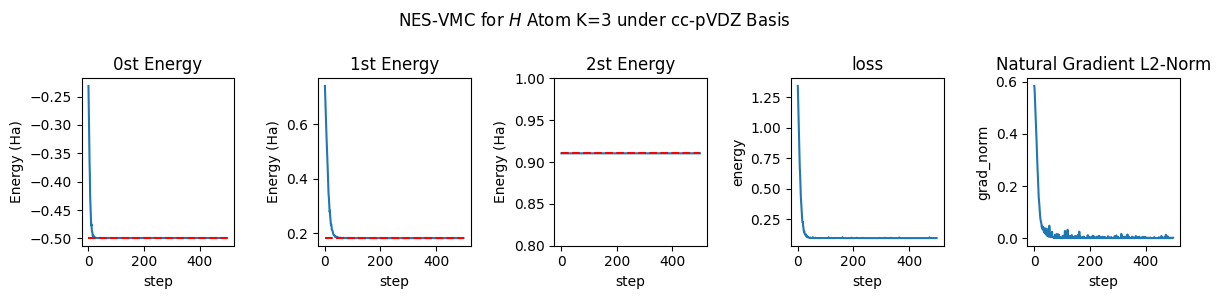

In [16]:
import matplotlib.pyplot as plt

# 创建 2行1列 的子图
fig, axs = plt.subplots(1, 5, figsize=(12, 3))
fig.suptitle('NES-VMC for $H$ Atom K=3 under cc-pVDZ Basis ')
# 第一个子图
axs[0].plot(history['energy_0st'])
axs[0].hlines(E_fcis[0],0,len(history['energy_0st']),linestyle='--',color='red')
axs[0].set_title('0st Energy')
axs[0].set_ylabel('Energy (Ha)')
axs[0].set_xlabel('step')

axs[1].plot(history['energy_2st'])
axs[1].hlines(E_fcis[1],0,len(history['energy_1st']),linestyle='--',color='red')
axs[1].set_title('1st Energy')
axs[1].set_ylabel('Energy (Ha)')
axs[1].set_xlabel('step')

axs[2].plot(history['energy_3st'])
axs[2].hlines(E_fcis[2],0,len(history['energy_2st']),linestyle='--',color='red')
axs[2].set_title('2st Energy')
axs[2].set_ylabel('Energy (Ha)')
axs[2].set_xlabel('step')
axs[2].set_ylim(bottom=0.8, top=1.0)


# 第二个子图
axs[3].plot(history['loss'])
axs[3].set_title('loss')
axs[3].set_xlabel('step')
axs[3].set_ylabel('energy')

# 第三个子图
axs[4].plot(history['grad_norm_natural'])
axs[4].set_title('Natural Gradient L2-Norm')
axs[4].set_xlabel('step')
axs[4].set_ylabel('grad_norm')

plt.tight_layout()  # 自动调整间距
plt.show()

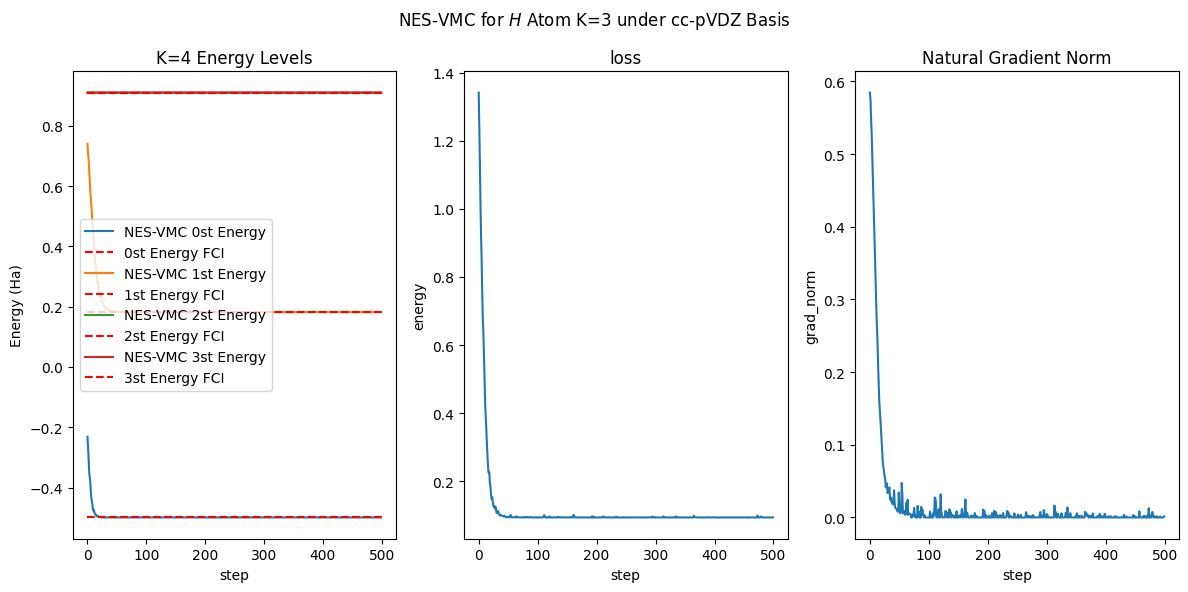

In [15]:
import matplotlib.pyplot as plt

# 创建 2行1列 的子图
fig, axs = plt.subplots(1, 3, figsize=(12, 6))
fig.suptitle('NES-VMC for $H$ Atom K=3 under cc-pVDZ Basis ')
# 第一个子图
axs[0].plot(history['energy_0st'],label='NES-VMC 0st Energy')
axs[0].hlines(E_fcis[0],0,len(history['energy_0st']),linestyle='--',color='red',label='0st Energy FCI')
axs[0].plot(history['energy_2st'],label='NES-VMC 1st Energy')
axs[0].hlines(E_fcis[1],0,len(history['energy_1st']),linestyle='--',color='red',label='1st Energy FCI')
axs[0].plot(history['energy_3st'],label='NES-VMC 2st Energy')   
axs[0].hlines(E_fcis[2],0,len(history['energy_2st']),linestyle='--',color='red',label='2st Energy FCI')
axs[0].plot(history['energy_3st'],label='NES-VMC 3st Energy')
axs[0].hlines(E_fcis[3],0,len(history['energy_3st']),linestyle='--',color='red',label='3st Energy FCI')

axs[0].set_title('K=4 Energy Levels')
axs[0].set_ylabel('Energy (Ha)')
axs[0].set_xlabel('step')
axs[0].legend()



# 第二个子图
axs[1].plot(history['loss'])
axs[1].set_title('loss')
axs[1].set_xlabel('step')
axs[1].set_ylabel('energy')

# 第三个子图
axs[2].plot(history['grad_norm_natural'])
axs[2].set_title('Natural Gradient Norm')
axs[2].set_xlabel('step')
axs[2].set_ylabel('grad_norm')

plt.tight_layout()  # 自动调整间距
plt.show()

剖析为啥有毛病 

In [ ]:
history['energy_0st'][40:45]

In [ ]:
from collections import Counter
import numpy as np
def sampler_info(samples:jnp.array,K:int):
    test_samples = np.array(samples.reshape(-1, 4*K))
    count = Counter(tuple(each_row.tolist()) for each_row in test_samples)
    for tpl, count_ in count.items():
        print(f"元组 {tpl} 出现了 {count_} 次")
    return count


sampler_info(history['samples'][100],K)

In [ ]:
sampler_info(history['samples'][102],K)

In [ ]:

print(f'我当时保存的: loss: {history["loss"][102]:.3f}|energy_0st: {history["energy_0st"][102]:.3f}|grad_norm: {history["grad_norm"][102]:.3f}')
test_samples = history['samples'][102]
test_params = history['params'][101]
# 3. 计算能量和自然梯度（逻辑和原代码一致）
grad, loss_mean, E_L_mean = nes_vmc_gradient(ha=ha,
                                                total_matrix_machine=total_matrix_machine,
                                                total_machine=total_machine,
                                                single_machine_list=single_machine_list,
                                                total_params=test_params,
                                                x_batch=test_samples.reshape(-1,K,4))

grad_flat , grad_unravel_fn = ravel_pytree(grad)
grad_norm = jnp.linalg.norm(grad_flat)

eig_vals, eig_vecs = jnp.linalg.eigh(E_L_mean)
print(f'我基于当时的 Samples 尝试复现:')
print(f"grad_norm: {grad_norm:.3f}|loss_mean: {loss_mean:.3f}|energy_0st: {eig_vals[0]:.3f}")
print(E_L_mean)

In [ ]:
from NES_VMC import NES_loss_energy

trace, E_L = NES_loss_energy(ha=ha,
                total_matrix_machine=total_matrix_machine,
                single_machine_list=single_machine_list,
                total_params=total_params,
                x=test_samples.reshape(-1,2,4))

trace

In [ ]:
test_samples.reshape(-1,2,4)[0]

In [ ]:
E_L[0]

In [ ]:
def NES_loss_energy(ha, total_matrix_machine,single_machine_list,total_params, x):
    log_M = total_matrix_machine(total_params,x)
    Psi_Matrix = jnp.exp(log_M)
    # 添加正则化项，防止矩阵奇异
    #Psi_Matrix += 1e-6 * jnp.eye(Psi_Matrix.shape[0])
    H_psi_x = Ham_Psi(ha,single_machine_list,total_params,x)
    Psi_Matrix_inv = jnp.linalg.solve(Psi_Matrix, H_psi_x)
    return jnp.real(jnp.trace(Psi_Matrix_inv, axis1=-2, axis2=-1)), Psi_Matrix_inv

In [ ]:
total_matrix_machine(total_params, history['samples'][41].reshape(-1,K,4))